In [1]:
# =============================================================
# Korean 3-Class Selection + HF Tokenization Pipeline
# Google Colab Version
# =============================================================

# -------------------------------------------------------------
# 0. Setup — Colab 패키지 설치
# -------------------------------------------------------------
# -------------------------------------------------------------
# 0. 패키지 설치 — 실행 환경 자동 감지
# -------------------------------------------------------------
import sys

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    import subprocess
    subprocess.run(["pip", "install", "-q", "koreanize-matplotlib"], check=True)


In [8]:
import os
import numpy as np
import pandas as pd
from transformers import AutoTokenizer
from sklearn.preprocessing import LabelEncoder
import math

SEED = 42
np.random.seed(SEED)
os.makedirs("figs", exist_ok=True)

In [3]:
# =============================================================
# Part A · Data Selection (3-Class Balanced)
# =============================================================


# 1. Load Dataset — 한국어만 사용
url = "https://raw.githubusercontent.com/hongsukyi/Lectures/main/data/aihub_conver.xlsx"

df_raw = pd.read_excel(url, engine="openpyxl")
df_raw = df_raw[["원문", "상황"]].dropna()

print(f"Total samples: {len(df_raw):,}")


Total samples: 100,000


##  EDA 1 — 데이터 기본 정보
`shape` / `info()` / `head()` 로 데이터를 처음 열었을 때의 3종 세트를 확인합니다.

In [4]:
# =============================================================
# EDA 1 · 데이터 기본 정보 (pandas 기본기)
# =============================================================

# (1) 크기: (행 개수, 열 개수) — 데이터를 받으면 가장 먼저 확인
print("데이터 크기 (행, 열):", df_raw.shape)

# (2) 열 이름 · 자료형 · 결측치 요약을 한 번에
df_raw.info()

# (3) 앞부분 5줄을 눈으로 확인 (숫자만 보지 말고 실제 값 보기)
df_raw.head()


데이터 크기 (행, 열): (100000, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   원문      100000 non-null  object
 1   상황      100000 non-null  object
dtypes: object(2)
memory usage: 1.5+ MB


,원문,상황
0,이번 신제품 출시에 대한 시장의 반응은 어떤가요?,의견 교환하기
1,판매량이 지난번 제품보다 빠르게 늘고 있습니다.,의견 교환하기
2,그렇다면 공장에 연락해서 주문량을 더 늘려야겠네요.,의견 교환하기
3,"네, 제가 연락해서 주문량을 2배로 늘리겠습니다.",의견 교환하기
4,지난 회의 마지막에 논의했던 안건을 다시 볼까요?,의견 교환하기


In [5]:
# (4) 결측치(빈 칸) 개수 — 섹션 1에서 dropna() 했으니 0이 정상
print("결측치 개수\n", df_raw.isnull().sum(), "\n")

# (5) 완전히 똑같은 중복 행 개수
print("중복 행 개수:", df_raw.duplicated().sum())

# (6) 문자열 열 요약: count / unique / top(최빈값) / freq(최빈 빈도)
df_raw.describe(include="object")


결측치 개수
 원문    0
상황    0
dtype: int64 

중복 행 개수: 2


,원문,상황
count,100000,100000
unique,99987,2779
top,"알겠습니다, 잠시만 기다려주세요.","직장에서의 일상 대화 (상사, 동료, 부하 간의 대화)"
freq,3,1320


In [6]:
# 2. Top-K Domain Check
label_counts = df_raw["상황"].value_counts()
top_k = label_counts.head(TOP_K)

print(f"\nTop {TOP_K} Classes")
for i, (label, cnt) in enumerate(top_k.items(), 1):
    print(f"{i:2d}. {label} ({cnt:,})")



Top 10 Classes
 1. 직장에서의 일상 대화 (상사, 동료, 부하 간의 대화) (1,320)
 2. 찬성 및 반대 (1,076)
 3. 취직 면접 상황 (1,032)
 4. 회의 관련 (1,020)
 5. 의견 교환하기 (1,016)
 6. 학교생활 (시험, 졸업, 입학 등) (976)
 7. 원하는 스타일에 대해 점원 or 친구와 대화 시술 전/시술 시/시술 후 대화 (948)
 8. 제안 및 협상하기 (924)
 9. CS/고객 상담 (고객 요청 대응: 취소, 반품, 결함 등) (832)
10. 마케팅/홍보 (804)


##  EDA 2 — 전체 클래스 분포
어떤 상황(클래스)이 많고 적은지, 불균형 정도를 눈으로 확인합니다.

전체 클래스 개수 : 2779종
최다 클래스     : 직장에서의 일상 대화 (상사, 동료, 부하 간의 대화) (1,320개)
최소 클래스     : 회식 중 상사가 개발한 앱이 1위하여 축하하는 상황 (1개)


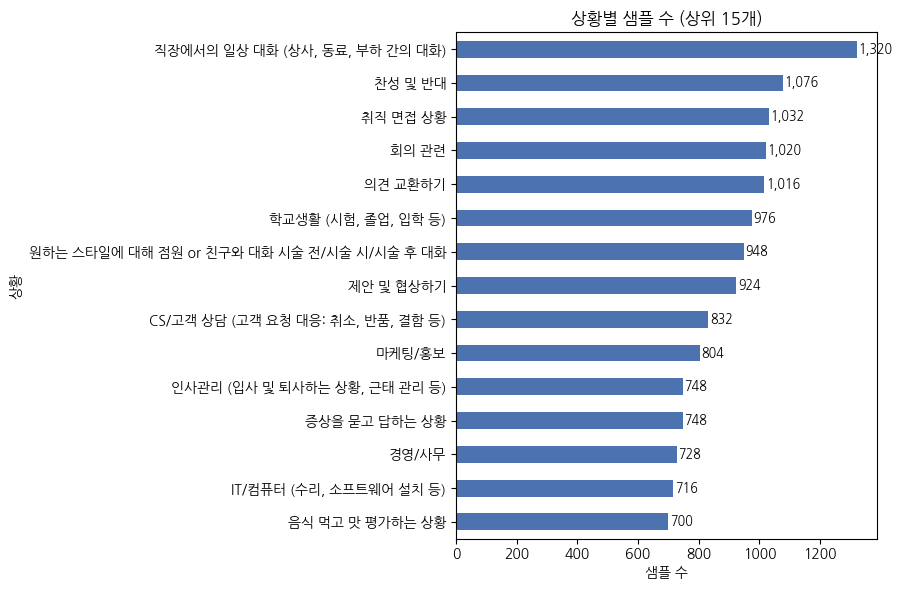

In [9]:
# =============================================================
# EDA 2 · 전체 클래스(상황) 분포 시각화
# =============================================================
import matplotlib.pyplot as plt
import koreanize_matplotlib   # 한글 깨짐 방지 (섹션 0에서 설치됨)

counts = df_raw["상황"].value_counts()

print(f"전체 클래스 개수 : {df_raw['상황'].nunique()}종")
print(f"최다 클래스     : {counts.idxmax()} ({counts.max():,}개)")
print(f"최소 클래스     : {counts.idxmin()} ({counts.min():,}개)")

# 클래스가 많으므로 상위 15개만 '가로 막대'로 (긴 라벨은 가로가 읽기 편함)
top_n = 15
fig, ax = plt.subplots(figsize=(9, 6))
counts.head(top_n)[::-1].plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title(f"상황별 샘플 수 (상위 {top_n}개)")
ax.set_xlabel("샘플 수")
for i, v in enumerate(counts.head(top_n)[::-1]):
    ax.text(v + 5, i, f"{v:,}", va="center", fontsize=9)
plt.tight_layout()
plt.show()


In [10]:
# -------------------------------------------------------------
# 3. Class Name Simplification
# -------------------------------------------------------------
label_map = {
    "직장에서의 일상 대화 (상사, 동료, 부하 간의 대화)": "직장",
    "찬성 및 반대": "찬반",
    "취직 면접 상황": "면접",
    "회의 관련": "회의",
    "의견 교환하기": "의견교환",
    "학교생활 (시험, 졸업, 입학 등)": "학교",
    "원하는 스타일에 대해 점원 or 친구와 대화 시술 전/시술 시/시술 후 대화": "시술상담",
    "제안 및 협상하기": "협상",
    "CS/고객 상담 (고객 요청 대응: 취소, 반품, 결함 등)": "고객",
    "마케팅/홍보": "마케팅",
}

df_raw["label_simple"] = df_raw["상황"].map(label_map)

n_unmapped = df_raw["label_simple"].isna().sum()
print(f"\nUnmapped labels: {n_unmapped:,}")

SELECT_LABELS = ["면접", "학교", "협상"]

df_sel = df_raw[df_raw["label_simple"].isin(SELECT_LABELS)].copy()

assert len(df_sel) > 0, \
    f"[ERROR] SELECT_LABELS {SELECT_LABELS} 에 해당하는 데이터가 없습니다."

print("\nSelected Classes:")
for lb in SELECT_LABELS:
    print(f"  - {lb} ({(df_sel['label_simple'] == lb).sum():,})")



Unmapped labels: 90,052

Selected Classes:
  - 면접 (1,032)
  - 학교 (976)
  - 협상 (924)


In [11]:
# -------------------------------------------------------------
# 4. Balanced Sampling
# -------------------------------------------------------------
SAMP = min(df_sel["label_simple"].value_counts().min(), 800)

df_clf = (
    df_sel.groupby("label_simple")
    .sample(n=SAMP, random_state=SEED)
    .reset_index(drop=True)
)

print("\nBalanced dataset size:", len(df_clf))


# =============================================================
# Part B · HuggingFace Tokenization
# =============================================================



Balanced dataset size: 2400


## EDA 3 — 3-class 균형 확인
균형 샘플링이 실제로 잘 맞았는지 막대·파이로 검증합니다.

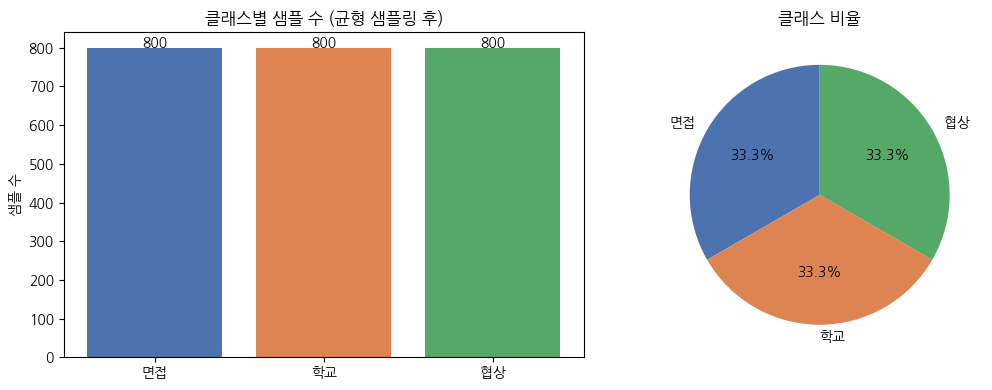

In [12]:
# =============================================================
# EDA 3 · 선택한 3-class 균형 확인
# =============================================================
import matplotlib.pyplot as plt
import koreanize_matplotlib

vc = df_clf["label_simple"].value_counts()
colors = ["#4C72B0", "#DD8452", "#55A868"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# (왼쪽) 막대: 클래스별 개수
axes[0].bar(vc.index, vc.values, color=colors)
axes[0].set_title("클래스별 샘플 수 (균형 샘플링 후)")
axes[0].set_ylabel("샘플 수")
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 3, str(v), ha="center")

# (오른쪽) 파이: 비율 — 세 조각이 거의 같으면 균형 OK
axes[1].pie(vc.values, labels=vc.index, autopct="%1.1f%%",
            colors=colors, startangle=90)
axes[1].set_title("클래스 비율")

plt.tight_layout()
plt.show()


In [13]:
# 5. Prepare Dataset
df = df_clf[["원문", "label_simple"]].copy()
df.rename(columns={"원문": "text", "label_simple": "label"}, inplace=True)

print("Final dataset size:", len(df))
print("-" * 60)


Final dataset size: 2400
------------------------------------------------------------


##  EDA 4 — 문장 길이 분포
토큰화 전에 '글자 수'로 길이 감을 잡고, MAX_LEN 설정의 근거를 마련합니다.

count    2400.0
mean       31.3
std         8.1
min         7.0
25%        26.0
50%        30.0
75%        35.0
max        81.0
Name: char_len, dtype: float64


/tmp/ipykernel_1077/3602924357.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([df_clf.loc[df_clf["label_simple"] == c, "char_len"]


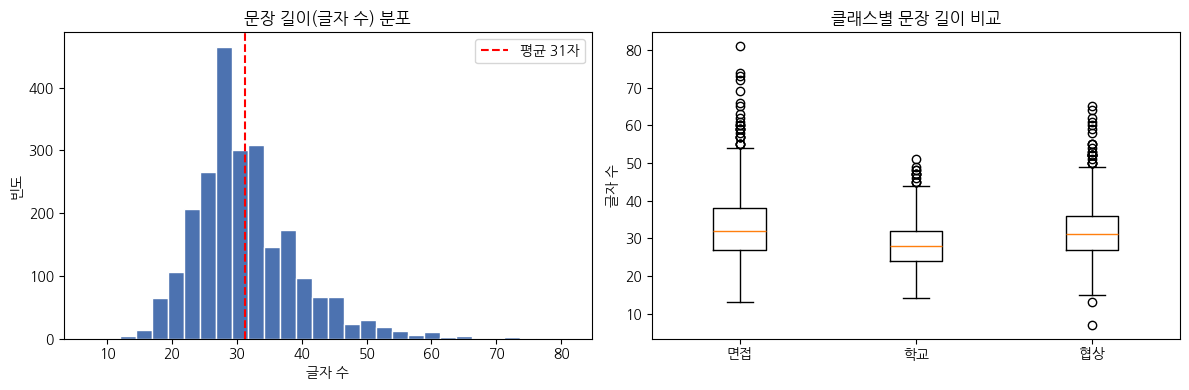

In [14]:
# =============================================================
# EDA 4 · 문장 길이 EDA (글자 수 기준, 초보자용)
# =============================================================
# 토큰 길이(섹션 7)와 별개로, 먼저 '글자 수'로 직관을 잡습니다.
import matplotlib.pyplot as plt
import koreanize_matplotlib

df_clf["char_len"] = df_clf["원문"].str.len()

print(df_clf["char_len"].describe().round(1))   # 평균/최소/최대/사분위수

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (왼쪽) 전체 글자 수 히스토그램
axes[0].hist(df_clf["char_len"], bins=30, color="#4C72B0", edgecolor="white")
axes[0].axvline(df_clf["char_len"].mean(), color="red", linestyle="--",
                label=f"평균 {df_clf['char_len'].mean():.0f}자")
axes[0].set_title("문장 길이(글자 수) 분포")
axes[0].set_xlabel("글자 수"); axes[0].set_ylabel("빈도")
axes[0].legend()

# (오른쪽) 클래스별 길이 비교(박스플롯) — 특정 클래스만 유독 길면 편향 신호
labels_uniq = df_clf["label_simple"].unique()
axes[1].boxplot([df_clf.loc[df_clf["label_simple"] == c, "char_len"]
                 for c in labels_uniq], labels=labels_uniq)
axes[1].set_title("클래스별 문장 길이 비교")
axes[1].set_ylabel("글자 수")

plt.tight_layout()
plt.show()


In [15]:
# 6. Load Tokenizer — Colab은 SSL 우회 불필요
MODEL_NAME = "klue/bert-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"Tokenizer: {MODEL_NAME}")
print(f"Vocab size: {tokenizer.vocab_size:,}")
print("-" * 60)


config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/248k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/495k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Tokenizer: klue/bert-base
Vocab size: 32,000
------------------------------------------------------------


In [16]:
# -------------------------------------------------------------
# 7. Automatic MAX_LEN (p95 기반)
# -------------------------------------------------------------
lengths = [len(tokenizer.tokenize(t)) for t in df["text"]]
p95, p99 = np.percentile(lengths, [95, 99])

special_tokens_count = tokenizer.num_special_tokens_to_add(pair=False)
margin = 2

raw_max_len = int(p95 + special_tokens_count + margin)
MAX_LEN = int(math.ceil(raw_max_len / 8) * 8)

print(f"p95: {p95:.0f}, p99: {p99:.0f}")
print(f"special tokens: {special_tokens_count}")
print(f"자동 설정 MAX_LEN: {MAX_LEN}")
print("-" * 60)


p95: 25, p99: 30
special tokens: 2
자동 설정 MAX_LEN: 32
------------------------------------------------------------


In [17]:
# -------------------------------------------------------------
# 8. Batch Tokenization
# -------------------------------------------------------------
encoded = tokenizer(
    df["text"].tolist(),
    padding="max_length",
    truncation=True,
    max_length=MAX_LEN,
    return_tensors=None
)

input_ids      = np.array(encoded["input_ids"],      dtype=np.int32)
attention_mask = np.array(encoded["attention_mask"], dtype=np.int32)

pad_id = tokenizer.pad_token_id

print(f"Encoded shape : {input_ids.shape}")
print("-" * 60)


# =============================================================
# Part C · Label Encoding + Single File Save
# =============================================================


Encoded shape : (2400, 32)
------------------------------------------------------------


In [18]:
# 9. Label Encoding
le = LabelEncoder()
labels = le.fit_transform(df["label"])
class_names = le.classes_.tolist()

print("Class names:", class_names)


Class names: ['면접', '학교', '협상']


In [19]:
# 10. Save — 단일 파일 완결형
n_total = len(df_clf)
fname = f"aihub_enko_conv_kluebert_3class_n{n_total}_v1.npz"

np.savez(
    fname,
    input_ids=input_ids,
    attention_mask=attention_mask,
    labels=labels,
    vocab_size=np.int32(tokenizer.vocab_size),
    max_len=np.int32(MAX_LEN),
    pad_id=np.int32(pad_id),
    num_classes=np.int32(len(class_names)),
    class_names=np.array(class_names)
)

print(f"\nSaved: {fname}")



Saved: aihub_enko_conv_kluebert_3class_n2400_v1.npz
